In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns    

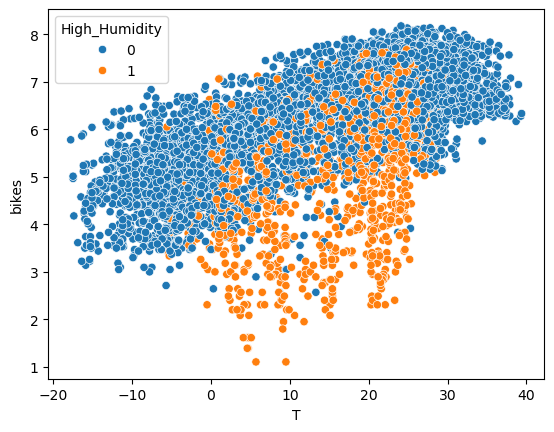

In [ ]:
df = pd.read_csv('train.csv')
df.columns
df.rename(columns={
'Rented_Bike_Count' : 'bikes',
'Humidity(%)' : 'H',
'Temperature(°C)': 'T',
'Wind speed (m/s)' : 'WS',
'Visibility (10m)': 'V',
'Dew point temperature(°C)' : 'DT',
'Solar Radiation (MJ/m2)': 'SR',
'Rainfall(mm)': 'RF',
'Snowfall (cm)':  'SF',
'Functioning Day': 'f_day'
 }, inplace=True)

e = 6.112 * np.exp((17.62 * df['DT']) / (243.12 + df['DT']))
df['ATemp'] = df['T'] + 0.33 * e - 0.7 * df['WS'] - 4
#sns.lineplot(data = df, x = 'T', y = 'bikes', errorbar=('ci', True)) 
df['Extreme_Hot'] = (df['T'] > 28).astype('int')
df['Extreme_cold'] = (df['T'] < -5).astype('int')
#df['bikes'] = np.expm1(df['bikes'])
def mod(a):
    if a < 0:
        return -a
    return a

df['Saturation'] = (df['T'] - df['DT']).apply(mod)

df['S_fall'] = (df['SF'] != 0).astype('int')
df['R_fall'] = (df['RF'] != 0).astype('int')


#sns.kdeplot(data = df, x = 'V', y = 'bikes', fill =  True, cmap = 'coolwarm', cbar= True)
#display(df)

df['V_size'] = (df['V'] > 700).astype('int')

d = {
    'No Holiday' : 0,
    'Yes' : 1,
    'No' : 0,
    'Holiday':1   
}

df['Holiday'] = df['Holiday'].map(d)
df['f_day'] = df['f_day'].map(d)
df = df[df['f_day'] != 0]


df['Date'] =pd.to_datetime(df['Date'], format="%d/%m/%Y")
df['DOW'] = df['Date'].dt.day_of_week

df['Weekend'] = ((df['DOW'] == 5) | (df['DOW'] == 6))
df['Weekend'] = df['Weekend'].astype('int')

m1 = df.groupby('DOW')['bikes'].mean()
df['DOW'] = df['DOW'].map(m1)


# df['DOM'] = df['Date'].dt.day
# m3 = df.groupby('DOM')['bikes'].mean()
# df['DOM'] = df['DOM'].map(m3)


df['Peak_Hour'] = df['Hour'].isin([7, 8, 9, 17, 18, 19]).astype(int)
df['WindChill'] = (13.12 + 0.6215*df['T']- 11.37*(df['WS']*3.6)**0.16+ 0.3965*df['T']*(df['WS']*3.6)**0.16)

df['Low_Humidity'] = (df['H'] < 30).astype(int)             
df['High_Humidity'] = (df['H'] > 80).astype(int)



def humid(a):
    if (a < 70):
        return 0
    else:
        return a - 70

            
df['Humidity_Grading'] = df['H'].apply(humid)

# sns.scatterplot(data=df, x = 'T', y = 'bikes', hue = 'High_Humidity')
# plt.show()
# plt.close()

df['Cold_Humid'] = ((df['T'] < 15) & (df['H'] > 75)).astype(int)

df['Fog'] = ((df['Saturation'] < 3) & (df['High_Humidity'] == 1)).astype(int)
df['Discomfort_Index'] = np.maximum(0, 15 - df['T']) * np.maximum(0, df['H'] - 70) / 100

df['High_SR'] = (df['SR'] > 1.5).astype(int) 
df['Low_SR']  = ((df['SR'] > 0 )&(df['SR'] <= 0.3)).astype(int)  

df['Night_time'] = df['Hour'].isin([21, 22, 23, 0, 1, 2, 3, 4, 5]).astype(int)



#sns.kdeplot(data=df, x = 'SR')



hour_map = df.groupby('Hour')['bikes'].mean()     
df['Hour_Encoded'] = df['Hour'].map(hour_map)






In [3]:
examine = df.sample(2000, random_state= 42)
#sns.scatterplot(data = examine, x= 'SR', y = 'bikes') #REMOVE SOLAR
#sns.scatterplot(data = examine, x= 'SF', y = 'bikes') #Major decrease while snowing itself.!!
#sns.scatterplot(data = examine, x= 'RF', y = 'bikes')  # When rf is > 5 there is little or no passage itself.
# fig, ax = plt.subplots()
# sns.scatterplot(data = examine, x= 'bikes', y = 'ATemp' , ax = ax) #The Values which are outside the -30 to 40 region are sparse and are predictable. 
# plt.tight_layout()                                            
# plt.show()
# plt.close() # mostly this column is of no use.

# fig, ax = plt.subplots()
# sns.scatterplot(data = examine, x= 'WS', y = 'bikes', hue= 'R_fall' , ax = ax, alpha = 0.4)
# plt.tight_layout() # WIND SPEED itself a guassian distribution, when mixed with rainfall the decrease is brutal.
# plt.show()
# plt.close()
# fig, ax = plt.subplots()
# sns.scatterplot(data = examine, x= 'WS', y = 'bikes', hue= 'S_fall' , ax = ax, alpha = 0.4) #The results are the same when paired with snowfall too!!
# plt.tight_layout()
# plt.show()
# plt.close()

# fig, ax = plt.subplots()
# sns.scatterplot(data = examine, x= 'Hour', y = 'bikes', hue= 'Extreme_Hot' , ax = ax, alpha = 0.2)
# plt.tight_layout()     # NOTHING USEFUL , HOUR _ ENCODED IS ENOUGH.
# plt.show()
# plt.close()

# fig, ax = plt.subplots()
# sns.scatterplot(data = examine, x= 'Saturation', y = 'bikes', hue = 'R_fall' , ax = ax)
# plt.tight_layout()     # NOTHING USEFUL , Used to predict rain and visibility, but not bikes.
                            #  Just use and remove.
# plt.show()
# plt.close()







In [4]:
df.drop(columns=['Id', 'Seasons', 'f_day','Date', 'Hour'], inplace=True)
df.describe()

,bikes,T,H,WS,V,DT,SR,RF,SF,Holiday,...,Low_Humidity,High_Humidity,Humidity_Grading,Cold_Humid,Fog,Discomfort_Index,High_SR,Low_SR,Night_time,Hour_Encoded
count,6528.000000,6528.000000,6528.000000,6528.000000,6528.000000,6528.000000,6528.000000,6528.000000,6528.000000,6528.000000,...,6528.000000,6528.000000,6528.000000,6528.000000,6528.000000,6528.000000,6528.000000,6528.000000,6528.00000,6528.000000
mean,5.971538,12.459314,57.880821,1.795251,1396.990656,3.587270,0.581245,0.158456,0.081893,0.047794,...,0.081648,0.178768,4.049020,0.104320,0.148744,0.168527,0.164828,0.134804,0.37500,5.971538
std,1.174452,13.191148,20.883274,1.056941,616.553509,14.398904,0.886102,1.186419,0.418201,0.213347,...,0.273849,0.383188,7.691345,0.305698,0.355863,0.565068,0.371054,0.341540,0.48416,0.602998
min,1.098612,-17.800000,0.000000,0.000000,27.000000,-30.600000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,4.551796
25%,5.247024,1.200000,42.000000,1.000000,881.000000,-7.700000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,5.841946
50%,6.052089,13.600000,57.000000,1.600000,1610.000000,4.700000,0.020000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,6.144770
75%,6.906004,23.725000,74.000000,2.400000,1987.000000,16.300000,0.930000,0.000000,0.000000,0.000000,...,0.000000,0.000000,4.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.00000,6.413076
max,8.176673,39.400000,98.000000,7.400000,2000.000000,27.200000,3.520000,35.000000,5.100000,1.000000,...,1.000000,1.000000,28.000000,1.000000,1.000000,4.158000,1.000000,1.000000,1.00000,6.834457


In [5]:
df2 = pd.read_csv('test.csv')

df2.rename(columns={
'Humidity(%)' : 'H',
'Temperature(°C)': 'T',
'Wind speed (m/s)' : 'WS',
'Visibility (10m)': 'V',
'Dew point temperature(°C)' : 'DT',
'Solar Radiation (MJ/m2)': 'SR',
'Rainfall(mm)': 'RF',
'Snowfall (cm)':  'SF',
'Functioning Day': 'f_day'
 }, inplace=True)

e2 = 6.112 * np.exp((17.62 * df2['DT']) / (243.12 + df2['DT']))
df2['ATemp'] = df2['T'] + 0.33 * e2 - 0.7 * df2['WS'] - 4


df2['Extreme_Hot'] = (df2['T'] > 28).astype('int')
df2['Extreme_cold'] = (df2['T'] < -5).astype('int')


df2['Saturation'] = (df2['T'] - df2['DT']).apply(mod)

df2['S_fall'] = (df2['SF'] != 0).astype('int')
df2['R_fall'] = (df2['RF'] != 0).astype('int')




df2['V_size'] = (df2['V'] > 700).astype('int')



df2['Holiday'] = df2['Holiday'].map(d)
df2['f_day'] = df2['f_day'].map(d)


df2['Date'] =pd.to_datetime(df2['Date'], format="%d/%m/%Y")

df2['DOW'] = df2['Date'].dt.day_of_week



df2['Weekend'] = ((df2['DOW'] == 5) | (df2['DOW'] == 6))
df2['Weekend'] = df2['Weekend'].astype('int')



df2['DOW'] = df2['DOW'].map(m1)


# df2['DOM'] = df2['Date'].dt.day
# df2['DOM'] = df2['DOM'].map(m3)


df2['Peak_Hour'] = df2['Hour'].isin([7, 8, 9, 17, 18, 19]).astype(int) 
df2['WindChill'] = (13.12 + 0.6215*df2['T']- 11.37*(df2['WS']*3.6)**0.16 + 0.3965*df2['T']*(df2['WS']*3.6)**0.16)

df2['Low_Humidity'] = (df2['H'] < 30).astype(int)
df2['High_Humidity'] = (df2['H'] > 80).astype(int)
df2['Humidity_Grading'] = df2['H'].apply(humid)

df2['Cold_Humid'] = ((df2['T'] < 15) & (df2['H'] > 75)).astype(int)
df2['Fog'] = ((df2['Saturation'] < 3) & (df2['High_Humidity'] == 1)).astype(int)

df2['Discomfort_Index'] = np.maximum(0, 15 - df2['T']) * np.maximum(0, df2['H'] - 70) / 100
df2['High_SR'] = (df2['SR'] > 1.5).astype(int)
df2['Low_SR']  = ((df2['SR'] > 0 )&(df2['SR'] <= 0.3)).astype(int)


df2['Night_time'] = df2['Hour'].isin([21, 22, 23, 0, 1, 2, 3, 4, 5]).astype(int)


     
df2['Hour_Encoded'] = df2['Hour'].map(hour_map)

test_data_id = df2['Id']

df2.drop(columns = ['Id', 'Seasons', 'Date', 'Hour'], inplace = True)
df2





,T,H,WS,V,DT,SR,RF,SF,Holiday,f_day,...,Low_Humidity,High_Humidity,Humidity_Grading,Cold_Humid,Fog,Discomfort_Index,High_SR,Low_SR,Night_time,Hour_Encoded
0,23.2,83,0.5,1887,20.1,0.0,0.0,0.0,0,1,...,0,1,13,0,0,0.0,0,0,1,5.899938
1,22.7,83,0.1,1940,19.6,0.0,0.0,0.0,0,1,...,0,1,13,0,0,0.0,0,0,1,5.694657
2,22.0,86,0.4,1703,19.5,0.0,0.0,0.0,0,1,...,0,1,16,0,1,0.0,0,0,1,5.360459
3,21.6,87,0.3,1579,19.3,0.0,0.0,0.0,0,1,...,0,1,17,0,1,0.0,0,0,1,4.957403
4,21.2,88,0.9,1183,19.1,0.0,0.0,0.0,0,1,...,0,1,18,0,1,0.0,0,0,1,4.551796
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2179,4.2,34,2.6,1894,-10.3,0.0,0.0,0.0,0,1,...,0,0,0,0,0,0.0,0,0,0,6.568920
2180,3.4,37,2.3,2000,-9.9,0.0,0.0,0.0,0,1,...,0,0,0,0,0,0.0,0,0,0,6.412897
2181,2.6,39,0.3,1968,-9.9,0.0,0.0,0.0,0,1,...,0,0,0,0,0,0.0,0,0,1,6.413611
2182,2.1,41,1.0,1859,-9.8,0.0,0.0,0.0,0,1,...,0,0,0,0,0,0.0,0,0,1,6.323614


In [ ]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

scaling_feature = ['T', 'DT', 'WS', 'H', 'V', 'RF', 'SF', 'SR', 'Saturation', 'Hour_Encoded', 'DOW', 'WindChill']

# for i in scaling_feature:
#     fig, ax = plt.subplots()
#     sns.kdeplot(data = df, x= i , ax = ax)
#     plt.tight_layout()   #Saturation, WS , Humidity are near Guassian, 
#                          #temp is a bimodal data, DT is a guassian with no peak.
#     plt.show()          #RF, SF, SR are heavily skewed data
#     plt.close()


scale1 = StandardScaler()

X_train = df.copy()
X_test = df2.copy()
X_test.drop(columns = ['f_day'], inplace = True)

X_train['RF'] = np.log1p(X_train['RF'])
X_train['SF'] = np.log1p(X_train['SF'])
X_train['SR'] = np.log1p(X_train['SR'])
X_train['WS'] = np.log1p(X_train['WS'])
X_train['V'] = np.log1p(X_train['V'])

X_test['RF'] = np.log1p(X_test['RF'])
X_test['SF'] = np.log1p(X_test['SF'])
X_test['SR'] = np.log1p(X_test['SR'])
X_test['WS'] = np.log1p(X_test['WS'])
X_test['V'] = np.log1p(X_test['V'])

X_train[scaling_feature] = scale1.fit_transform(X_train[scaling_feature])
X_test[scaling_feature] = scale1.transform(X_test[scaling_feature])
y_train = X_train['bikes']
X_train = X_train.drop(columns = 'bikes')
# display(X_test)
# X_train_s = X_train.copy()
# X_train_r = X_train.copy()

# X_test_s = X_test.copy()
# X_test_r = X_test.copy()
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train = poly.fit_transform(X_train)
X_test = poly.fit_transform(X_test)

scale2 = MinMaxScaler(feature_range=(0.1, 1.1))
X_train = scale2.fit_transform(X_train)
X_test = scale2.transform(X_test)


display(X_train)
display(X_test)




,T,H,WS,V,DT,SR,RF,SF,Holiday,ATemp,...,Low_Humidity,High_Humidity,Humidity_Grading,Cold_Humid,Fog,Discomfort_Index,High_SR,Low_SR,Night_time,Hour_Encoded
0,0.814297,1.202929,-1.480961,0.693368,1.146892,-0.743159,-0.206438,-0.221588,0,26.595325,...,0,1,13,0,0,0.0,0,0,1,-0.118750
1,0.776390,1.202929,-2.311338,0.734600,1.112165,-0.743159,-0.206438,-0.221588,0,26.139106,...,0,1,13,0,0,0.0,0,0,1,-0.459209
2,0.723320,1.346596,-1.665676,0.540653,1.105219,-0.743159,-0.206438,-0.221588,0,25.182628,...,0,1,16,0,1,0.0,0,0,1,-1.013480
3,0.692994,1.394485,-1.864085,0.428128,1.091328,-0.743159,-0.206438,-0.221588,0,24.760429,...,0,1,17,0,1,0.0,0,0,1,-1.681950
4,0.662668,1.442374,-0.848078,-0.001583,1.077437,-0.743159,-0.206438,-0.221588,0,23.849231,...,0,1,18,0,1,0.0,0,0,1,-2.354654
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2179,-0.626173,-1.143626,0.862929,0.698880,-0.964541,-0.743159,-0.206438,-0.221588,0,-0.694962,...,0,0,0,0,0,0.0,0,0,0,0.990763
2180,-0.686825,-0.999959,0.629974,0.779941,-0.936759,-0.743159,-0.206438,-0.221588,0,-1.255305,...,0,0,0,0,0,0.0,0,0,0,0.731998
2181,-0.747476,-0.904181,-1.864085,0.755931,-0.936759,-0.743159,-0.206438,-0.221588,0,-0.655305,...,0,0,0,0,0,0.0,0,0,1,0.733182
2182,-0.785383,-0.808404,-0.710751,0.671115,-0.929814,-0.743159,-0.206438,-0.221588,0,-1.637760,...,0,0,0,0,0,0.0,0,0,1,0.583921


array([[0.32027972, 0.47755102, 0.64653392, ..., 1.1       , 0.82410085,
        0.1       ],
       [0.31503497, 0.4877551 , 0.37618547, ..., 1.1       , 0.71384269,
        0.13558059],
       [0.30629371, 0.49795918, 0.4256916 , ..., 1.1       , 0.53434117,
        0.28318013],
       ...,
       [0.83951049, 0.89591837, 0.47047534, ..., 1.1       , 1.1       ,
        0.19465209],
       [0.83251748, 0.91632653, 0.40159023, ..., 1.1       , 1.05166185,
        0.15910404],
       [0.82727273, 0.92653061, 0.32084232, ..., 1.1       , 0.9011262 ,
        0.10001473]], shape=(6528, 495))

array([[0.81678322, 0.94693878, 0.29051737, ..., 1.1       , 0.82410085,
        0.1       ],
       [0.80804196, 0.94693878, 0.14478374, ..., 1.1       , 0.71384269,
        0.13558059],
       [0.7958042 , 0.97755102, 0.25809944, ..., 1.1       , 0.53434117,
        0.28318013],
       ...,
       [0.45664336, 0.49795918, 0.22327805, ..., 1.1       , 1.1       ,
        0.19465209],
       [0.4479021 , 0.51836735, 0.4256916 , ..., 1.1       , 1.05166185,
        0.15910404],
       [0.44440559, 0.53877551, 0.49136205, ..., 1.1       , 0.9011262 ,
        0.10001473]], shape=(2184, 495))

In [7]:
from sklearn.linear_model import LinearRegression, Lasso, Ridge
lr = LinearRegression().fit(X_train, y_train)

lr.score(X_train, y_train)

from sklearn.metrics import root_mean_squared_error

val_predictions = lr.predict(X_train)

# Calculate and print the Root Mean Squared Error (RMSE)
val_rmse = root_mean_squared_error(y_train, (val_predictions))
print(f"Local Validation RMSE: {val_rmse:.4f}")

Local Validation RMSE: 0.3763


In [8]:
lasso = Lasso(alpha= 0.1)
lasso.fit(X_train, y_train)

print(lasso.score(X_train, y_train))



val_predictions = lasso.predict(X_train)

# Calculate and print the Root Mean Squared Error (RMSE)
val_rmse = root_mean_squared_error(y_train, val_predictions)
print(f"Local Validation RMSE: {val_rmse:.4f}")
print(lasso.coef_)

0.4070212744008722
Local Validation RMSE: 0.9043
[ 0.9067669  -0.          0.          0.          0.          0.
 -0.         -0.         -0.          0.          0.         -0.
  0.         -0.         -0.          0.          0.         -0.
  0.          0.          0.         -0.         -0.         -0.
 -0.3971205  -0.          0.          0.         -0.          0.63471036
 -0.         -0.          0.          0.         -0.         -0.
 -0.          0.          0.          0.          0.          0.
  0.          0.         -0.          0.         -0.          0.
  0.         -0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.         -0.
 -0.          0.          0.         -0.         -0.         -0.
 -0.         -0.         -0.         -0.          0.          0.
 -0.         -0.         -0.          0.         -0.         -0.
 -0.         -0.         -0.         -0.         -0.         -0.
 -0.         -0.         -0.     

In [9]:
ridge = Ridge(alpha=7.0, random_state=42, max_iter=10000)
ridge.fit(X_train, y_train)

print(ridge.score(X_train, y_train))



val_predictions = ridge.predict(X_train)

# Calculate and print the Root Mean Squared Error (RMSE)
val_rmse = root_mean_squared_error(y_train, val_predictions)
print(f"Local Validation RMSE: {val_rmse:.4f}")

0.8809325227204117
Local Validation RMSE: 0.4052


,Id,Rented_Bike_Count
count,2184.000000,2184.000000
mean,7667.500000,6.282354
std,630.610815,0.931904
min,6576.000000,2.078237
25%,7121.750000,5.694698
50%,7667.500000,6.495339
75%,8213.250000,6.965444
max,8759.000000,8.029102


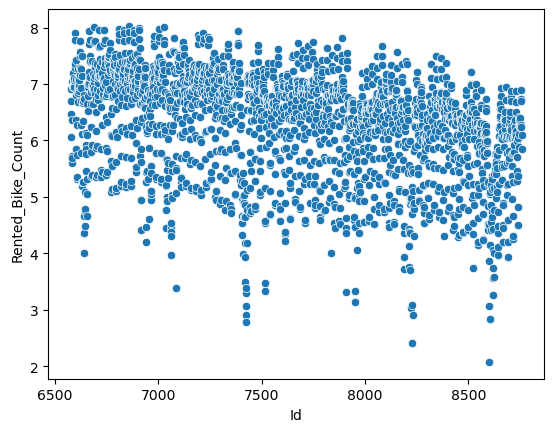

In [10]:
test_predictions = ridge.predict(X_test)

# Create the submission dataframe
submission = pd.DataFrame({
    'Id': test_data_id,
    'Rented_Bike_Count': test_predictions
})

# Display the first few rows of the submission
display(submission.describe())
sns.scatterplot(data = submission, x = 'Id', y = 'Rented_Bike_Count')
plt.show()
plt.close()


submission.iloc[submission[df2['f_day'] == 0].index, 1] = 0
# Export to CSV (without the pandas index)
submission.to_csv('submission1000.csv', index=False) #CSV20. 

In [11]:
display(submission.describe())
(submission['Rented_Bike_Count'] >= 0).value_counts()

,Id,Rented_Bike_Count
count,2184.000000,2184.000000
mean,7667.500000,5.549649
std,630.610815,2.168131
min,6576.000000,0.000000
25%,7121.750000,5.197766
50%,7667.500000,6.309913
75%,8213.250000,6.883542
max,8759.000000,8.029102


Rented_Bike_Count
True    2184
Name: count, dtype: int64

Local Validation RMSE: 0.0880


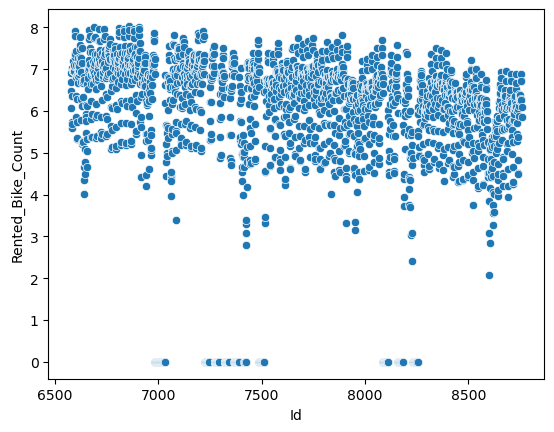

In [12]:
submission.describe()
sns.scatterplot(data = submission, x = 'Id', y = 'Rented_Bike_Count')
df3 = pd.read_csv('submission20.csv')
val_rmse = root_mean_squared_error(df3['Rented_Bike_Count'], submission['Rented_Bike_Count'])
print(f"Local Validation RMSE: {val_rmse:.4f}")

In [13]:
submission.describe()

,Id,Rented_Bike_Count
count,2184.000000,2184.000000
mean,7667.500000,5.549649
std,630.610815,2.168131
min,6576.000000,0.000000
25%,7121.750000,5.197766
50%,7667.500000,6.309913
75%,8213.250000,6.883542
max,8759.000000,8.029102


In [14]:
# xst = df[df['S_fall'] == 1]
# xrt = df[df['R_fall'] == 1]
# xst['bikes'] = np.expm1(xst['bikes'])
# xrt['bikes'] = np.expm1(xrt['bikes'])
# display(xst.describe())
# display(xrt.describe())
# xrt['Ext_Humidity'] = (xrt['H'] > 80).astype('int')  
# xst['Ext_Humidity'] = (xst['H'] > 80).astype('int') 
# xrt['Ext_Wind'] = (xrt['WS'] > 2).astype('int')
# xst['Ext_Wind'] = (xst['WS'] > 2).astype('int')
# # xrt['com'] = xrt['S_fall'] + xrt['Ext_Humidity']
# # sns.scatterplot(data = xrt, x= 'RF', y = 'bikes', hue = 'Ext_Wind', palette = 'coolwarm')
# # plt.show()  #Snowfall, holiday, Rainfall, Visibilty, Humidity, Ok.
# # plt.close()
# # sns.scatterplot(data = xst, x= 'SF', y = 'bikes', hue = 'Ext_Wind')
# # plt.show()   #Ext_Wind is a good predictor for snowfall.
# # plt.close()
# # # sns.barplot(data = xst, x = 'SF', y = 'bikes')
# # # plt.show()
# # # plt.close()
# # # sns.barplot(data = xrt, x = 'RF', y = 'bikes')

# # xrt[xrt['S_fall'] == 1]
# # xrst = xrt[xrt['S_fall'] == 1]
# # sns.scatterplot(data = xrst, x = 'RF', y = 'bikes', hue = 'Holiday')
# fig, ax = plt.subplots(figsize=(20, 20))
# sns.heatmap(data = xrt.corr(), annot = True, cmap = 'coolwarm', fmt='.1f', ax = ax)
# plt.show()
# plt.close()
# fig, ax = plt.subplots(figsize=(20, 20))
# sns.heatmap(data = xst.corr(), annot = True, cmap = 'coolwarm', fmt='.1f', ax = ax)
# plt.show()
# plt.close()


    

In [15]:
df4 = pd.DataFrame(
    {
    'Index' :df2[df2['f_day'] == 0].index
    }
    )
df4.to_csv('Index.csv', index = False)